# Exploratory Data Analysis

**Target:** `TARGET` (1 = client with payment difficulties, 0 = repaid). 


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
# readable numbers: no scientific notation; 1 decimal for large values, 3 for [0,1] scores
pd.set_option("display.float_format", lambda x: f"{x:,.1f}" if abs(x) >= 1 else f"{x:.3f}")
RANDOM_STATE = 42
FIGURES_DIR = "../reports/figures"

df = pd.read_csv("../data/raw/application_train.csv")
df.shape

(307511, 122)

## 1. Shape & structure

Before any cleaning, I map each column to its *measurement scale* rather than trusting its pandas dtype — the two don't align here. Several `int64`/`float64` columns are actually binary flags (`FLAG_*`) or ordinal ratings (`REGION_RATING_CLIENT`), not continuous quantities. That distinction, not the storage type, decides what later gets scaled versus encoded.

In [2]:
df.dtypes.value_counts()

float64    65
int64      41
str        16
Name: count, dtype: int64

In [3]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,"202,500.0","406,597.5","24,700.5",...,0,0,0,0,0.000,0.000,0.000,0.000,0.000,1.0
1,100003,0,Cash loans,F,N,N,0,"270,000.0","1,293,502.5","35,698.5",...,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000
2,100004,0,Revolving loans,M,Y,Y,0,"67,500.0","135,000.0","6,750.0",...,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000
3,100006,0,Cash loans,F,N,Y,0,"135,000.0","312,682.5","29,686.5",...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,"121,500.0","513,000.0","21,865.5",...,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000


**Takeaway:** the 122 columns fall into four scales — continuous (`AMT_*`, `DAYS_*`, `EXT_SOURCE_*`), binary flags (`FLAG_*`), 16 nominal text categoricals, and a ~47-column block of collinear building statistics (`_AVG`/`_MEDI`/`_MODE` triplets). Preprocessing therefore needs a `ColumnTransformer` with distinct branches: scale the continuous columns, one-hot the categoricals, pass the flags through untouched.

## 2. Missing values

Missingness is the first filter on the feature set — mostly-empty columns carry little signal and complicate imputation. I rank every column by missing rate to decide what to drop, but rate alone isn't a sufficient criterion: some gaps are *structural* (a field that simply doesn't apply to certain clients), and some sit on columns that could still turn out to be predictive despite the missingness. Columns flagged by the threshold get a closer look before being cut, not an automatic drop.

In [4]:
missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
THRESHOLD = 50
cols_above = missing_pct[missing_pct > THRESHOLD]
print(f"{len(cols_above)} columns above {THRESHOLD}% missing")
cols_above.head(15)

41 columns above 50% missing


COMMONAREA_AVG             69.9
COMMONAREA_MODE            69.9
COMMONAREA_MEDI            69.9
NONLIVINGAPARTMENTS_MEDI   69.4
NONLIVINGAPARTMENTS_MODE   69.4
NONLIVINGAPARTMENTS_AVG    69.4
FONDKAPREMONT_MODE         68.4
LIVINGAPARTMENTS_AVG       68.4
LIVINGAPARTMENTS_MEDI      68.4
LIVINGAPARTMENTS_MODE      68.4
FLOORSMIN_MODE             67.8
FLOORSMIN_AVG              67.8
FLOORSMIN_MEDI             67.8
YEARS_BUILD_AVG            66.5
YEARS_BUILD_MODE           66.5
dtype: float64

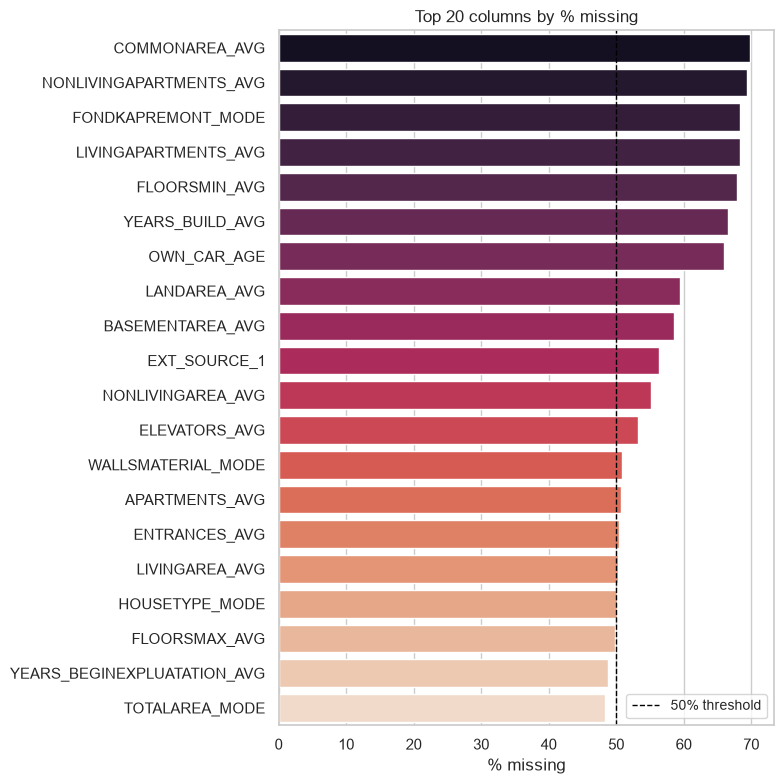

In [5]:
# The building _AVG/_MEDI/_MODE variants share identical missingness; collapse to the _AVG representative 
# for a readable plot (keeping metrics that exist only as _MODE).
avg_bases = {c[:-4] for c in missing_pct.index if c.endswith("_AVG")}
redundant = [c for c in missing_pct.index
             if (c.endswith("_MEDI") or c.endswith("_MODE")) and c[:-5] in avg_bases]
missing_pct_plot = missing_pct.drop(redundant)

top = missing_pct_plot.head(20)
fig, ax = plt.subplots(figsize=(8, 8))
sns.barplot(x=top.values, y=top.index, hue=top.index, palette="rocket", legend=False, ax=ax)
ax.axvline(THRESHOLD, color="black", linestyle="--", linewidth=1, label=f"{THRESHOLD}% threshold")
ax.set_xlabel("% missing")
ax.set_ylabel("")
ax.set_title("Top 20 columns by % missing")
ax.legend(loc="lower right", fontsize=10)
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/missing_values_top20.png", dpi=150)
plt.show()

### Structural missingness

`OWN_CAR_AGE` is 66% missing, but the gap looks structural rather than random — a car's age is undefined for clients who own no car. If that's the cause, the missingness should line up exactly with `FLAG_OWN_CAR = 'N'`:

In [6]:
pd.crosstab(df["FLAG_OWN_CAR"], df["OWN_CAR_AGE"].isna(),
            rownames=["FLAG_OWN_CAR"], colnames=["OWN_CAR_AGE missing"])

OWN_CAR_AGE missing,False,True
FLAG_OWN_CAR,,
N,0,202924
Y,104582,5


**Takeaway:** 41 columns exceed 50% missingness — but that headline count is inflated by redundancy: they collapse to just **17 distinct features**, since 12 building metrics are each counted three times as `_AVG`/`_MEDI`/`_MODE` variants of the same measurement. Two columns stand apart from that block: `OWN_CAR_AGE` (66% missing, but *structurally* — blank exactly when the client owns no car, per the crosstab above) and `EXT_SOURCE_1` (56% missing, but a normalized external score — a pre-built summary signal from outside the application, worth carrying forward for inspection rather than dropping on missingness alone). Missingness rate alone is therefore a misleading filter here — most "high-missing" columns are duplicates of one another, and the rest deserve a closer look before any are dropped.

## 3. Target distribution

The share of defaults decides which evaluation metric is meaningful and whether the classes need rebalancing during training. So it is the first thing to quantify.

In [7]:
target_counts = df["TARGET"].value_counts()
target_pct = df["TARGET"].value_counts(normalize=True) * 100
pd.DataFrame({"count": target_counts, "pct": target_pct.round(2)})

,count,pct
TARGET,,
0,282686,91.9
1,24825,8.1


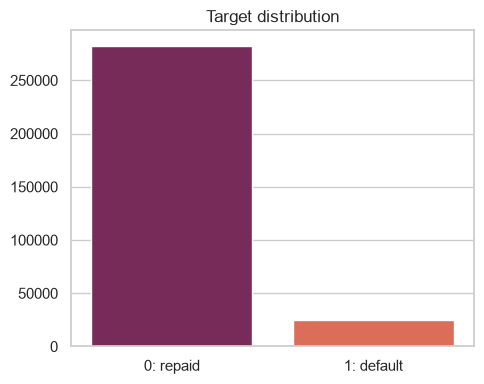

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x="TARGET", hue="TARGET", palette="rocket", legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["0: repaid", "1: default"])
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Target distribution")
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/target_distribution.png", dpi=150)
plt.show()

**Takeaway:** the target is heavily imbalanced — roughly 8% of applicants defaulted. This shapes the modelling approach in two ways:

- **Metrics.** Accuracy is uninformative — predicting "repaid" for everyone already scores ~92% while catching zero defaulters. Model selection instead uses the threshold-free ranking metrics **ROC-AUC** and **PR-AUC** (average precision), the latter more sensitive to the rare default class since its no-skill baseline is the ~8% prevalence rather than the fixed 0.5 of ROC-AUC. Threshold-dependent metrics — precision, recall, F1 — and the decision cutoff will be set later, weighted toward catching defaults given the asymmetric cost of a missed one.
- **Training.** The imbalance must be addressed at training time — through class weights or resampling — otherwise a model will optimise for the majority class and under-predict the defaults that actually matter.

## 4. Numeric features

Rather than sweep all ~100 numeric columns, I profile three groups chosen for their expected relevance to credit risk: the loan-burden amounts, the client's age and employment tenure, and the external scores.

**4a. Loan burden.** `AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_ANNUITY`, `AMT_GOODS_PRICE` — what the client earns versus how much they are borrowing and repaying.

In [9]:
amt_cols = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"]
df[amt_cols].describe()

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE
count,"307,511.0","307,511.0","307,499.0","307,233.0"
mean,"168,797.9","599,026.0","27,108.6","538,396.2"
std,"237,123.1","402,490.8","14,493.7","369,446.5"
min,"25,650.0","45,000.0","1,615.5","40,500.0"
25%,"112,500.0","270,000.0","16,524.0","238,500.0"
50%,"147,150.0","513,531.0","24,903.0","450,000.0"
75%,"202,500.0","808,650.0","34,596.0","679,500.0"
max,"117,000,000.0","4,050,000.0","258,025.5","4,050,000.0"


In [10]:
df[amt_cols].skew().round(1)

AMT_INCOME_TOTAL   391.6
AMT_CREDIT           1.2
AMT_ANNUITY          1.6
AMT_GOODS_PRICE      1.3
dtype: float64

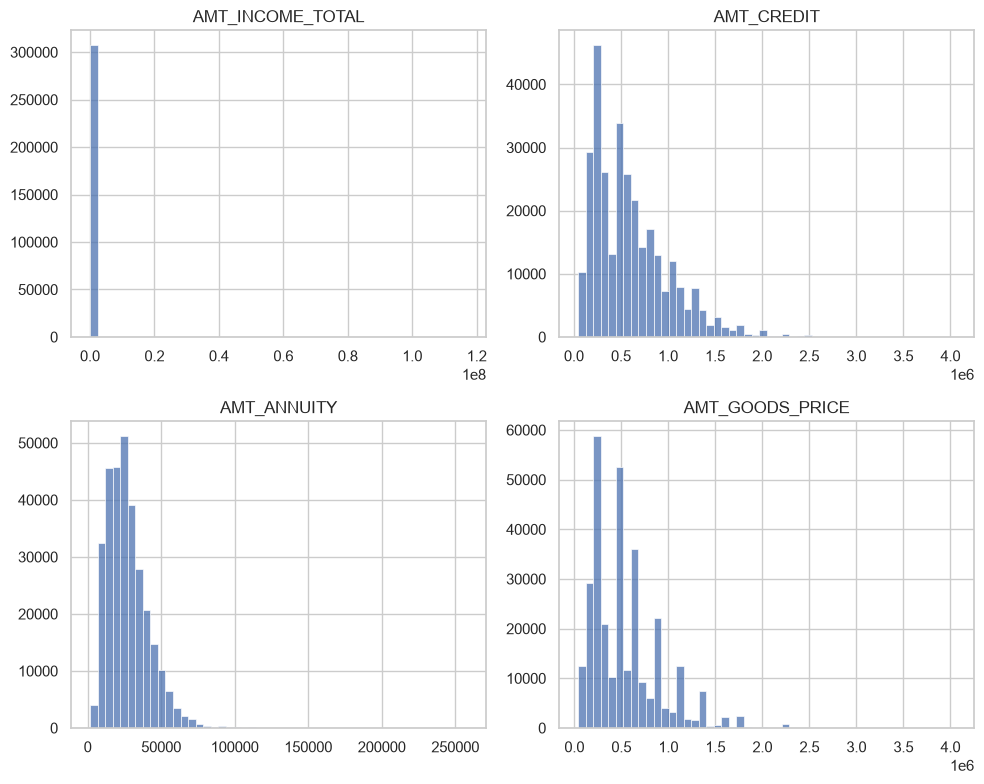

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.flat, amt_cols):
    sns.histplot(df[col].dropna(), bins=50, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("")
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/amt_distributions.png", dpi=150)
plt.show()

In [12]:
df["AMT_INCOME_TOTAL"].nlargest(5)

12840    117,000,000.0
203693    18,000,090.0
246858    13,500,000.0
77768      9,000,000.0
131127     6,750,000.0
Name: AMT_INCOME_TOTAL, dtype: float64

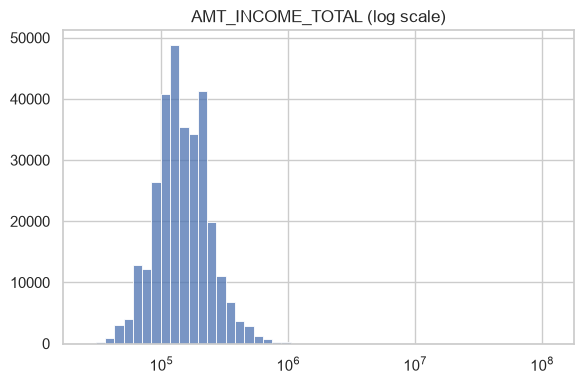

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(df["AMT_INCOME_TOTAL"].dropna(), bins=50, log_scale=True, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("AMT_INCOME_TOTAL (log scale)")
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/amt_income_log.png", dpi=150)
plt.show()

**Takeaway:** all four amounts are right-skewed, and `AMT_INCOME_TOTAL` is the extreme case — its skewness is ~390 (versus low single digits for the others), driven by a single value of 117M against a next-highest of 18M that makes the raw histogram unreadable. On a log scale the distribution becomes roughly symmetric — approximately log-normal — which justifies a `log1p` transform for the linear models; the tree models are scale-invariant and can take it without such transformation. 

**4b. Age and employment tenure.** `DAYS_BIRTH` and `DAYS_EMPLOYED`, both recorded as days before the application (hence negative). I convert age to years for readability and sanity-check both against plausible ranges.

In [14]:
age_years = (-df["DAYS_BIRTH"] / 365.25).round(1).rename("AGE_YEARS")
age_years.describe()

count   307,511.0
mean         43.9
std          11.9
min          20.5
25%          34.0
50%          43.1
75%          53.9
max          69.1
Name: AGE_YEARS, dtype: float64

In [15]:
df["DAYS_EMPLOYED"].describe()

count   307,511.0
mean     63,815.0
std     141,275.8
min     -17,912.0
25%      -2,760.0
50%      -1,213.0
75%        -289.0
max     365,243.0
Name: DAYS_EMPLOYED, dtype: float64

In [16]:
placeholder = df["DAYS_EMPLOYED"].max()
anomaly_mask = df["DAYS_EMPLOYED"] == placeholder
print(f"{anomaly_mask.sum():,} rows ({anomaly_mask.mean() * 100:.1f}%) share the maximum value {placeholder:,}")

breakdown = df.loc[anomaly_mask, "NAME_INCOME_TYPE"].value_counts()
pct = (breakdown / anomaly_mask.sum() * 100).map("{:.2f}".format)
pd.DataFrame({"count": breakdown, "pct": pct})

55,374 rows (18.0%) share the maximum value 365,243


,count,pct
NAME_INCOME_TYPE,,
Pensioner,55352,99.96
Unemployed,22,0.04


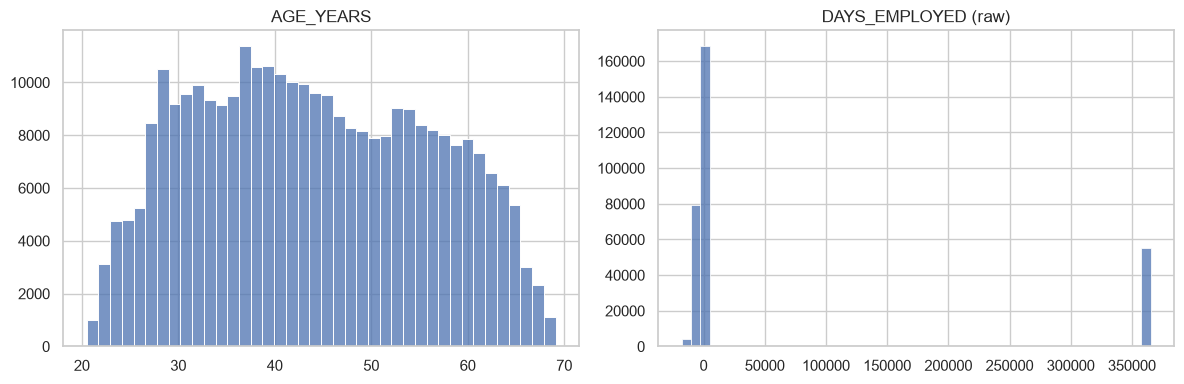

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(age_years, bins=40, ax=axes[0])
axes[0].set_title("AGE_YEARS")
axes[0].set_xlabel("")
axes[0].set_ylabel("")
sns.histplot(df["DAYS_EMPLOYED"], bins=50, ax=axes[1])
axes[1].set_title("DAYS_EMPLOYED (raw)")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/age_and_days_employed.png", dpi=150)
plt.show()

**Takeaway:** age is clean (20–69 years). `DAYS_EMPLOYED` is not: its maximum is a positive 365243 — about 1,000 years, and the wrong sign for a "days before application" field — carried by ~18% of rows. Those rows are almost entirely `Pensioner` or `Unemployed`, i.e. clients with no current job, so the value is a placeholder standing in for "not applicable". Fed to a model as a literal number it would distort the fit, so it must be recoded during preprocessing rather than left as a real duration.

**4c. External scores.** `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3`. The documentation says only "normalized score from external data source" — three pre-computed scores sourced from outside the application, with no disclosed meaning. Worth profiling as-is; whether they carry predictive signal is a question for the bivariate analysis, not an assumption here.

In [18]:
ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
df[ext_cols].describe()

,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
count,"134,133.0","306,851.0","246,546.0"
mean,0.502,0.514,0.511
std,0.211,0.191,0.195
min,0.015,0.000,0.001
25%,0.334,0.392,0.371
50%,0.506,0.566,0.535
75%,0.675,0.664,0.669
max,0.963,0.855,0.896


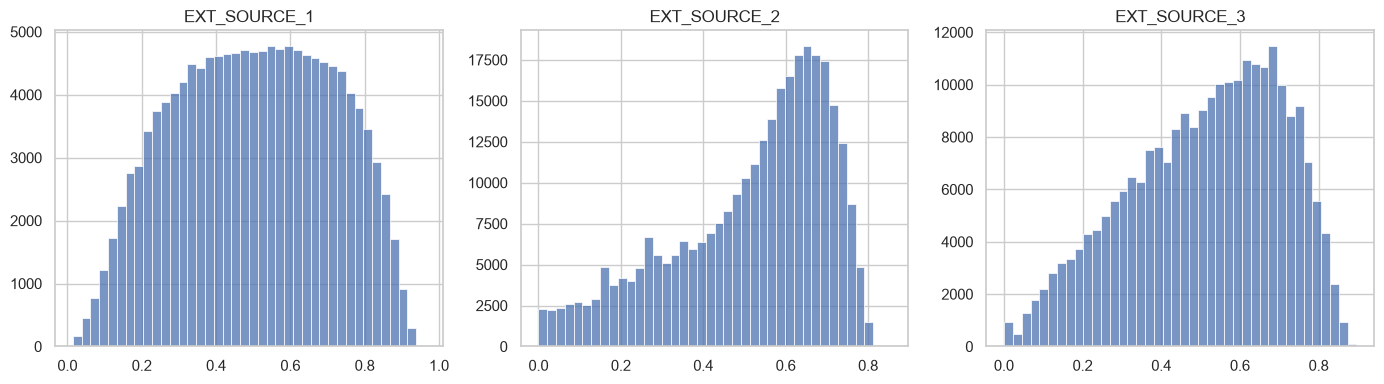

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ext_cols):
    sns.histplot(df[col].dropna(), bins=40, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("")
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/ext_source_distributions.png", dpi=150)
plt.show()

**Takeaway:** all three scores are bounded in [0, 1] and centred near 0.5 — consistent with normalised indices. Their completeness differs sharply, though: `EXT_SOURCE_2` is almost fully populated while `EXT_SOURCE_1` is over half missing. All three are carried forward to the bivariate step, where their relationship with the target is actually measured rather than assumed.

## 5. Categorical features

A curated subset of the nominal columns: `NAME_CONTRACT_TYPE`, `CODE_GENDER`, `NAME_EDUCATION_TYPE`, `NAME_FAMILY_STATUS`, `OCCUPATION_TYPE` — a mix of low- and high-cardinality fields.

In [20]:
cat_cols = ["NAME_CONTRACT_TYPE", "CODE_GENDER", "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS", "OCCUPATION_TYPE"]
for col in cat_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()

--- NAME_CONTRACT_TYPE ---
NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64

--- CODE_GENDER ---
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

--- NAME_EDUCATION_TYPE ---
NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree                     164
Name: count, dtype: int64

--- NAME_FAMILY_STATUS ---
NAME_FAMILY_STATUS
Married                 196432
Single / not married     45444
Civil marriage           29775
Separated                19770
Widow                    16088
Unknown                      2
Name: count, dtype: int64

--- OCCUPATION_TYPE ---
OCCUPATION_TYPE
NaN                      96391
Laborers                 55186
Sales staff              32102
Core staff               27570
Managers                 21371
Drivers                  18603
High skill tec

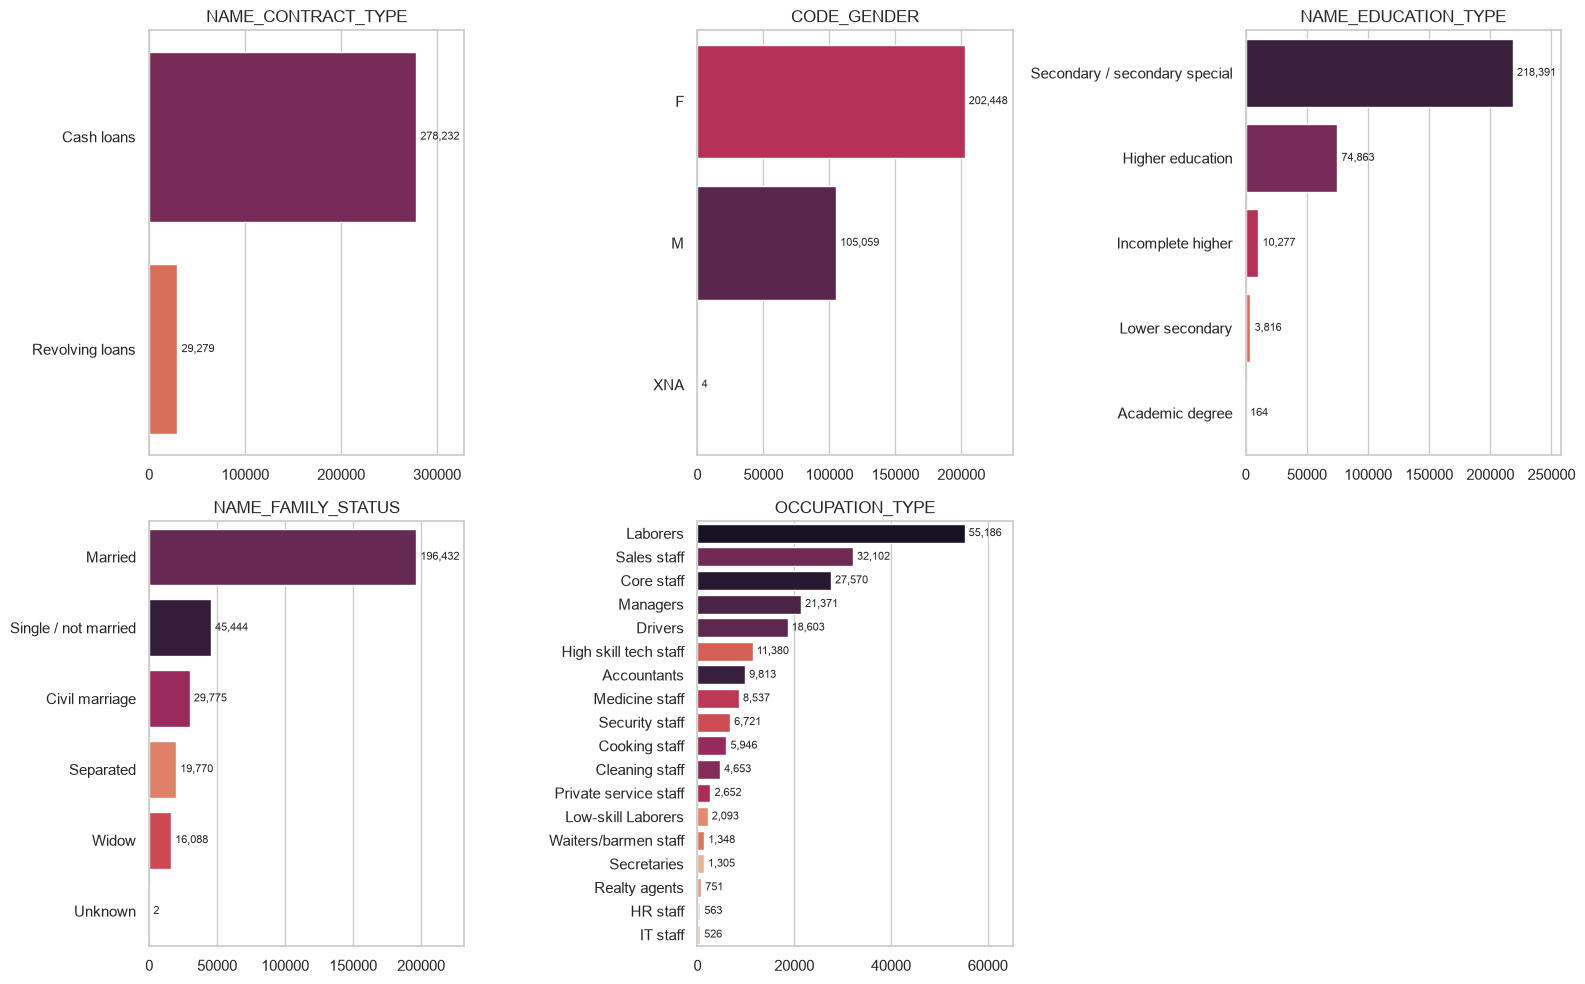

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, col in zip(axes.flat, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, hue=col, palette="rocket", legend=False, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("")
    for container in ax.containers:
        ax.bar_label(container, fmt="{:,.0f}", padding=3, fontsize=8)
    ax.margins(x=0.18)
axes.flat[-1].axis("off")
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/categorical_distributions.png", dpi=150)
plt.show()

In [22]:
df.loc[df["OCCUPATION_TYPE"].isna(), "NAME_INCOME_TYPE"].value_counts()

NAME_INCOME_TYPE
Pensioner               55357
Working                 24920
Commercial associate    12297
State servant            3787
Unemployed                 22
Student                     5
Businessman                 2
Maternity leave             1
Name: count, dtype: int64

**Takeaway:** two fields contain a handful of placeholder values with no real meaning — `CODE_GENDER = 'XNA'` (4 rows) and `NAME_FAMILY_STATUS = 'Unknown'` (2 rows); at six rows out of 307k, dropping them is cleaner than carrying a near-empty category. `OCCUPATION_TYPE` needs more care: it's ~31% missing — partly structural (pensioners have no occupation) but largely just unrecorded for working clients, so it's better kept as an explicit "Missing" category than imputed to a mode that would invent information. It's also high-cardinality (18 values, several under ~800 rows), so grouping the rare categories into broader buckets before encoding would reduce sparsity. Education and occupation both show wide, interpretable spreads worth revisiting against default rate in the bivariate analysis.